# Phase 1: Data Exploration

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

# 1. Load the emotion dataset
print("Loading dair-ai/emotion dataset...")
dataset = load_dataset("dair-ai/emotion")
df_train = pd.DataFrame(dataset['train'])



Loading dair-ai/emotion dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [2]:
# Map integer labels to their actual string names for readability based on the dataset card
label_mapping = {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}
df_train['emotion_name'] = df_train['label'].map(label_mapping)


In [3]:
df_train

,text,label,emotion_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger
...,...,...,...
15995,i just had a very brief time in the beanbag an...,0,sadness
15996,i am now turning and i feel pathetic that i am...,0,sadness
15997,i feel strong and good overall,1,joy
15998,i feel like this was such a rude comment and i...,3,anger


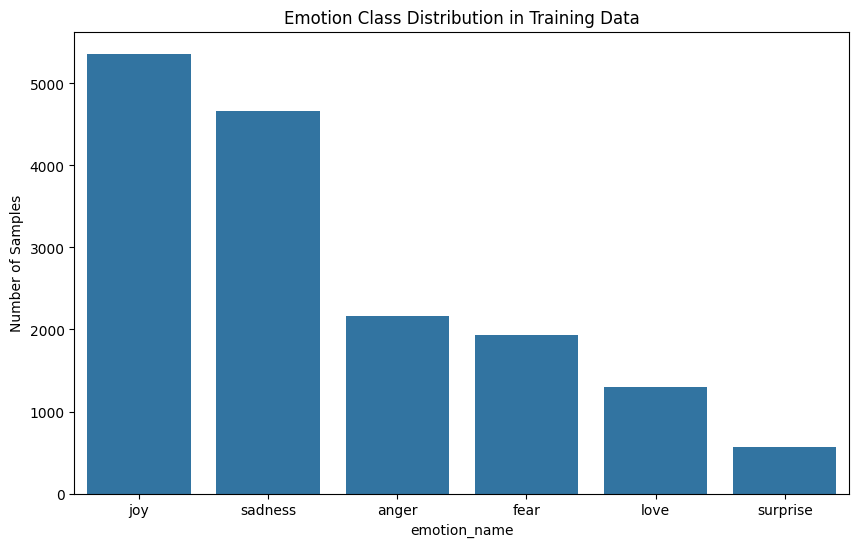

In [4]:
# 2. Check Class Distribution (Crucial for Emotion Data!)
plt.figure(figsize=(10, 6))
sns.countplot(data=df_train, x='emotion_name', order=df_train['emotion_name'].value_counts().index)
plt.title('Emotion Class Distribution in Training Data')
plt.ylabel('Number of Samples')
plt.show()


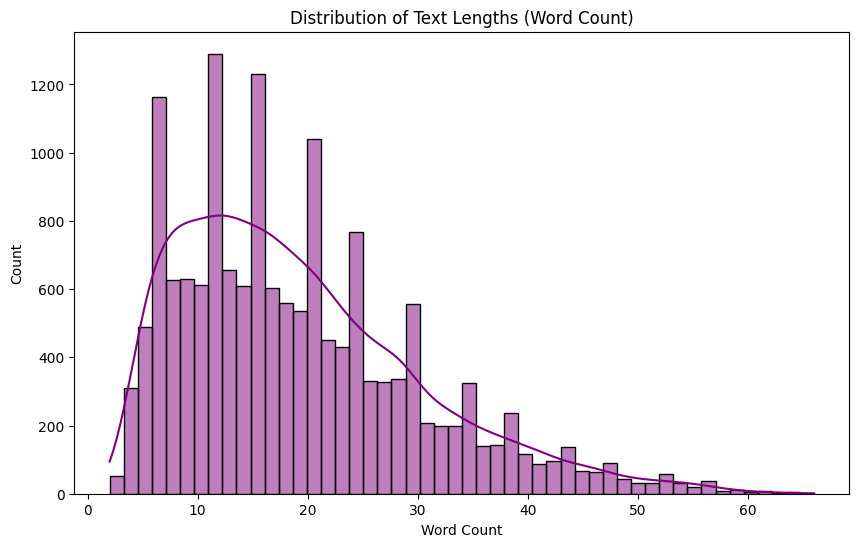


Summary Statistics for Word Count:
count    16000.000000
mean        19.166313
std         10.986905
min          2.000000
25%         11.000000
50%         17.000000
75%         25.000000
max         66.000000
Name: word_count, dtype: float64


In [5]:

# 3. Text Length Analysis (Words)
# Since deep learning models process sequences, word count dictates our max_length padding
df_train['word_count'] = df_train['text'].apply(lambda x: len(x.split()))
plt.figure(figsize=(10, 6))
sns.histplot(df_train['word_count'], bins=50, kde=True, color='purple')
plt.title('Distribution of Text Lengths (Word Count)')
plt.xlabel('Word Count')
plt.show()

print("\nSummary Statistics for Word Count:")
print(df_train['word_count'].describe())

# Phase 2: Tokenization and Dataset Preparation

In [6]:
from transformers import AutoTokenizer

# 1. Initialize the Tokenizer
# We use DistilBERT because it retains 97% of BERT's language understanding but is 60% faster
model_ckpt = "distilbert-base-uncased"
print(f"Loading tokenizer for {model_ckpt}...")
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

# 2. Define the Tokenization Function
# Based on your EDA, a max_length of 80 is more than enough to cover the max word count of 66
# (accounting for sub-word tokenization). We'll use 128 just to be absolutely safe for edge cases.
def tokenize_text(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

# 3. Apply Tokenization to the Dataset
print("Tokenizing the dataset...")
# Using batched=True applies this highly efficiently across multiple CPU cores
encoded_dataset = dataset.map(tokenize_text, batched=True)

# Let's inspect the keys to ensure 'input_ids' and 'attention_mask' were created
print("\nDataset structure after tokenization:")
print(encoded_dataset['train'].features)

Loading tokenizer for distilbert-base-uncased...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing the dataset...


Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]


Dataset structure after tokenization:
{'text': Value('string'), 'label': ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']), 'input_ids': List(Value('int32')), 'token_type_ids': List(Value('int8')), 'attention_mask': List(Value('int8'))}


# Phase 3: Class Weights and Model Architecture

In [8]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.2 MB/s eta 0:00:00


In [9]:
import torch
from torch import nn
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

import evaluate

# 1. Compute Class Weights
labels = encoded_dataset['train']['label']
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

# Move weights to the correct hardware device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

print("Calculated Class Weights:", np.round(class_weights, 4))

# 2. Subclass the Trainer to inject the weights into the loss function
class WeightedLossTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        # Apply CrossEntropyLoss with the dynamically calculated weights
        loss_fct = nn.CrossEntropyLoss(weight=class_weights_tensor)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

# 3. Initialize the DistilBERT Model
id2label = {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}
label2id = {v: k for k, v in id2label.items()}

print("\nInitializing DistilBERT sequence classifier...")
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=6,
    id2label=id2label,
    label2id=label2id
).to(device)

Calculated Class Weights: [0.5715 0.4973 2.045  1.2351 1.3767 4.662 ]

Initializing DistilBERT sequence classifier...


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


# Phase 4: Training and Serialization

In [17]:
# 1. Define Evaluation Metrics
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    # Calculate Accuracy and Macro F1
    acc = accuracy_metric.compute(predictions=predictions, references=labels)
    f1 = f1_metric.compute(predictions=predictions, references=labels, average="macro")

    return {"accuracy": acc["accuracy"], "f1_macro": f1["f1"]}

# 2. Configure Training Arguments (UPDATED)
training_args = TrainingArguments(
    output_dir="./emotion_model_checkpoints",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_steps=100,
    report_to="none"
)

# 3. Instantiate our Custom Trainer
trainer = WeightedLossTrainer(
    model=model,
    args=training_args,
    train_dataset=encoded_dataset["train"],
    eval_dataset=encoded_dataset["validation"],
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)
# 4. Train the Model
print("Starting training loop...")
trainer.train()

# 5. Serialize the Final System
save_directory = "./final_emotion_classifier"
trainer.save_model(save_directory)
tokenizer.save_pretrained(save_directory)
print(f"Module 2 complete. Model and tokenizer serialized to: {save_directory}")

Starting training loop...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.297438,0.240165,0.913500,0.889037
2,0.192863,0.177650,0.934500,0.912509
3,0.136436,0.171998,0.933500,0.910955


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Module 2 complete. Model and tokenizer serialized to: ./final_emotion_classifier


# Phase 5: Evaluation and inference

In [19]:
import torch
import numpy as np
from datasets import load_dataset
from transformers import AutoModelForSequenceClassification, AutoTokenizer, Trainer, TrainingArguments
import evaluate

# 1. Load the Serialized Model and Tokenizer
model_dir = "./final_emotion_classifier"
print(f"Loading model from {model_dir}...")
tokenizer = AutoTokenizer.from_pretrained(model_dir)
model = AutoModelForSequenceClassification.from_pretrained(model_dir)

# 2. Load and Tokenize the Unseen Test Data
print("Loading test dataset...")
dataset = load_dataset("dair-ai/emotion")
test_dataset = dataset['test']

def tokenize_text(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

print("Tokenizing test data...")
encoded_test = test_dataset.map(tokenize_text, batched=True)

# 3. Define Metrics
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=predictions, references=labels)
    f1 = f1_metric.compute(predictions=predictions, references=labels, average="macro")
    return {"accuracy": acc["accuracy"], "f1_macro": f1["f1"]}

# 4. Use Trainer for Evaluation
# We don't need all the training args, just enough to tell Trainer how to batch the evaluation
eval_args = TrainingArguments(
    output_dir="./tmp",
    per_device_eval_batch_size=32,
    report_to="none"
)

evaluator = Trainer(
    model=model,
    args=eval_args,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

# 5. Run Final Evaluation
print("\nRunning evaluation on unseen test set...")
results = evaluator.evaluate(encoded_test)
print(f"\nFinal Test Accuracy: {results['eval_accuracy']:.4f}")
print(f"Final Test F1 Macro: {results['eval_f1_macro']:.4f}")

Loading model from ./final_emotion_classifier...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading test dataset...
Tokenizing test data...


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]


Running evaluation on unseen test set...



Final Test Accuracy: 0.9255
Final Test F1 Macro: 0.8909


In [20]:
import torch
import torch.nn.functional as F
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import pandas as pd

# 1. Load the Model and Tokenizer
model_dir = "./final_emotion_classifier"
try:
    print(f"Loading model from {model_dir}...")
    tokenizer = AutoTokenizer.from_pretrained(model_dir)
    model = AutoModelForSequenceClassification.from_pretrained(model_dir)
    print("Model loaded successfully!\n")
except Exception as e:
    print(f"Error loading model: {e}")
    exit()

# Move model to appropriate device (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval() # Set model to evaluation mode (disables dropout layers)

# 2. Define Test Queries (Mental Health Context)
test_queries = [
    "I just got a promotion at work and I want to celebrate!",             # Joy
    "I feel so empty lately, like nothing I do matters anymore.",          # Sadness
    "My chest is tight and I keep thinking something terrible will happen.", # Fear
    "I am so frustrated! Why does my therapist keep canceling on me?!",    # Anger
    "I can't believe how much support my friends have shown me today.",    # Love/Surprise/Joy
    "Wait, did they really change the entire exam schedule overnight?",    # Surprise
]

# 3. Inference Loop
results = []

print("Running inference...\n")
with torch.no_grad(): # Disable gradient calculation for faster inference
    for text in test_queries:
        # Tokenize the input (convert text to tensor)
        inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=128)
        inputs = {k: v.to(device) for k, v in inputs.items()}

        # Forward pass through the model
        outputs = model(**inputs)
        logits = outputs.logits

        # Apply Softmax to convert raw logits into probability percentages
        probabilities = F.softmax(logits, dim=-1).squeeze()

        # Get the highest probability and its corresponding label
        confidence, predicted_class_idx = torch.max(probabilities, dim=0)
        predicted_label = model.config.id2label[predicted_class_idx.item()]

        results.append({
            "User Query": text,
            "Predicted Emotion": predicted_label,
            "Confidence": f"{confidence.item() * 100:.2f}%"
        })

# 4. Display Results
results_df = pd.DataFrame(results)
pd.set_option('display.max_colwidth', None)
print(results_df.to_string(index=False))

Loading model from ./final_emotion_classifier...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Model loaded successfully!

Running inference...

                                                           User Query Predicted Emotion Confidence
              I just got a promotion at work and I want to celebrate!               joy     98.39%
           I feel so empty lately, like nothing I do matters anymore.           sadness     99.31%
My chest is tight and I keep thinking something terrible will happen.           sadness     97.04%
     I am so frustrated! Why does my therapist keep canceling on me?!             anger     99.31%
     I can't believe how much support my friends have shown me today.               joy     95.61%
     Wait, did they really change the entire exam schedule overnight?              fear     82.53%
